In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from model.model import MLP
from src.model import VQVAE
import yaml
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
import umap
from sklearn.cluster import AgglomerativeClustering

In [26]:
brain = torch.tensor([  64072,  124480,  172290,    3530,  200325,  131023,   38002,  114456,
         104906,   21892,  171186,   72218,   42289,   38380,   31507,   46398,
           8789,   68002,  100490,  167192,   77869,  158425,  204991,   25157,
          73661,   12637,   26592,   29783,   57834,  138436,    3708,   29230,
         221118,   35737,    4570,  183373,   19199,  261143,    1562,  281509,
         137022,   42345, 1163192,   74303,   62535,  111403,   47851,   34569,
          46788,   73546,   12400,   93854,  304902,   62748,    9449,  105311,
          71998,   93917,   52469,   11324,  246999,   77413,   21540,   86451,
         131805,   62436,  125747,   16524,   45647,   52073,   40337,   36966,
         103115,  202264,  117472,  119659,   12566,  110110,   95544,   39119,
          35094,   40823,  111815,   16724,   33620,   23931,   56324,   13645,
           5128,   32017,   42480,  220331,  302937,   61144,   76105,  357914,
          16216,  188623,   77531,    2763,   52261,  126209,   58970,  322074,
          28915,   69741,  115273,   52466,  108188,   32453,   31543,  101129,
         102988,  190871,   31877,  373232,   22909,   73581,   14722,  305170,
         137515,  575022,   41592,  239942,  180174,   22716,  189105,   43610,
         110290,   65892,  242780,   28988,   66589,  143458,  108142,   16695,
          40828,  157953,   48959,  196096,   42674,  187921,   18226,  226602,
         162808,   33227,   38018,   40650,   17308,   67108,   91563,   10349,
          20201,  333625,   79674,   30912,    5860,   45939,   37499,    9360,
         402200,  252062,   57167,   61825,  109815,  968561,  235449,   78779,
          48051,  447897,    7332,   48664,   50833,   27973,   38725,    2321,
           5102,  135784,   98238,  129876,  167152,  161260,   33678,    2983,
          74131,  307598,   46383,  251709,  442592,   77082,  170083,   82480,
         130532,   43665,  313474,   14373,   50525,   14742,   43148,  528122,
          15346,  169263,   83338,   39105,  283552,  133185,   20780,    4575,
         212652,   77563,  259129,  477151,    5652,   28614,   44820,    9145,
          25806,  146386,   57833,  412090,  139528,   12562,  285940,   29294,
          10683,  360312,  148663,   54102,  355809,   35240,   61558,   20595,
          64778,   28747,   14725,  186052,  260573,  133158,   14375,   64560,
         176684,   76259,  152165,   21152,   98191,    9480,   14841,   70432,
         135126,  434999,   49790,   22107,   76905,   17778,    3641,   34076])

In [27]:
heart = torch.tensor([  14575,  129789,   69577,    5022,   19974,  232786,   22243,   97268,
          32159,   10946,  134884,  162914,   85232,   32973,   17485,   54321,
          43006,   22436,  121344,  277872,   19232,  557529,   81049,   30700,
          17810,   19848,   18978,   25231,   50894,   53125,    8209,   12176,
         421540,   71826,   33291,   46669,   49462,  203293,    5778,  306025,
          28332,   54306, 2270474,   50066,   21015,  160035,   18522,   40299,
          14289,   32518,    6829,   28630,   49524,   74004,   63773,   30862,
         235239,  270788,   30526,   44654,   82547,   22616,    9673,  129005,
         160250,  205203,   22863,   28796,   11466,   35663,   23806,   21992,
         137299,   46910,  123538,  121640,   54624,   14227,   22938,   55511,
          13555,   75786,   16660,   50527,   12801,   34221,   69452,    6527,
          21653,   22625,   38009,  169372,  342973,   10343,   30658,  184688,
          17065, 1482708,   53515,    3518,  118039,   44601,   29146,   54790,
          51025,   78609,   29155,   10021,   51601,    9326,   22383,   60124,
         326674,  120562,   13032,   41770,   22191,   45143,   15139,   52951,
         960484,  164002,   19011,  366133,   21009,    8161,  375064,   21316,
         105709,   13165,  563502,   29821,   93293,   61049,   34747,   75661,
          37155,  282494,   29191,  529979,   38712,  862318,   54145,  188701,
          16837,   65586,   12322,   63139,   33094,   95894,   33343,   35673,
           7943,   33409,   34248,   46395,   30347,   68065,   21986,   18639,
         642174,   94586,   17206,   84483,  503395,   96543,   28541,   12263,
          48407,   77334,   12098,   29512,   12993,   28217,  124350,   53507,
          25990,   54352,  294363,   14563,  116865,   25197,   29428,    1369,
          21257,  463578,   87013,   40734,  111795,   58702,   93662,   35785,
         127597,   18854,  865407,   44064,  101174,   29219,   29202,  138684,
          11142,   82017,   69352,   73127,  120038,   23082,   12851,   11809,
        1271578,   18394,   61852,  539795,   19819,   26244,   25034,    7083,
          39886,  326783,   15932,  156229,  236489,   12396,   28946,   25111,
          31392,   29950,   13329,   61770,   42350,   23288,   21382,    8959,
          90858,   12624,    4362,   89024,  293953,   95961,    6467,   98833,
          21956,   33251,  660121,   12855,  164120,   63239,   62277,   67313,
          33893,  235351,   16894,   25227,  106212,   25689,   39340,   71417])

In [28]:
kidney = torch.tensor([ 106909,   68949,  119390,   18728,  232231,  522639,   20761,  107840,
          69941,   13482,   93794,  169092,   71768,   40703,   33143,   41466,
          28641,   88510,  135319,  436079,  113797,  318735,  104593,   37330,
          56506,   20121,   47637,   21518,   68880,  126852,   15232,   21223,
         638771,   21789,    7304,  101964,   19460,  180160,    9616,  176309,
          53517,   59607, 1625972,   99471,   60143,  148885,   41072,   25299,
          28993,   94942,   17635,   88539,  138663,   46540,   13290,   77180,
         428660,  338221,   49450,   30096,  151420,   71887,   26711,  215274,
          80228,  203258,   53732,   43818,   38476,   40398,   33818,   45793,
          69320,   86327,  135910,   76297,   22136,  172966,   37779,   36214,
          20455,   39429,   49090,   21077,   49300,   15005,   79082,   13393,
          33820,  103803,   42854,   96946,  194206,   84750,   73773,  234400,
          17311,  463491,   33957,    5186,  118229,  104293,   34451,  132936,
          30487,   91308,   98779,   49615,  140586,   26252,   74548,   82573,
         353632,  209315,   22812,  135882,   24227,  178610,   35319,  110719,
        1605289,  219131,   28609,  213017,  109476,   32331,  123627,   72055,
         100685,   42620,  185881,   36599,   40226,  110460,   44038,   32712,
          64316,  108937,   57726,  101961,   30042,  259779,   21650,  101564,
          92195,   45461,   39724,   54602,   15641,   96877,   39429,    9183,
          12142,  204648,   68916,   42241,   31378,   82765,   49825,   25077,
         340884,  213724,   60264,   87531,  429436,  268834,   60681,   82495,
          38821,  150035,    7399,   61192,   62725,   31664,   88819,   12598,
          21894,  123865,  275804,   54419,  150663,   86156,   34148,    3423,
          42185,  600800,   30714,  153308,  160271,   94108,  144143,   43643,
          93067,   22979,  205750,   16851,   51182,   20909,   33726,  268285,
          13445,  110731,   92504,   32374,  138658,   84271,   33590,   35266,
         150232,   38694,  338547,  206637,    7275,   39131,   48091,   13536,
          86654,  603509,   67039,  176986,  426260,   11254,  112694,   26271,
          17126,  150431,   66853,   45287,  122982,   22515,   29209,   51933,
          40612,   16163,   12950,   96450,  356627,  220298,   13881,  123679,
          73608,   38621,  151542,   28028,  266089,   16621,   13529,   77299,
         176214,  191585,   57077,   25735,  151793,   25454,   11603,   23819])

In [29]:
liver = torch.tensor([148210, 147961,  95916,  26984, 252541, 121953,  99182, 158940,  61095,
         96697, 172086, 169874, 166290,  49806,  21569, 116231,  62132, 200047,
        130673, 147987, 198719, 141513, 158496,  47954,  72213,  20455,  43381,
         10806,  89584,  48981,  35862,  69007, 122313,  91370,  17951,  79925,
        106981, 139847,   4180, 144220,  77664, 125549, 737303,  62489,  47926,
        149926,  39834,  84657,  87071, 165016,  21540,  70533,  81350, 176055,
         52830,  89838, 133636,  87191,  52808,  94824,  90319,  32809,  23555,
        139233, 257660, 200796,  86277, 128240,  58807, 142402, 106942,  26955,
        187206, 121015, 117240, 188980, 105647, 173026,  95312, 107548,   9749,
        132473,  73254,  78210,  70119,  62629, 218473,  43750,  36955, 255251,
         71679, 167131, 181925, 254407,  36703, 126487,  12575,  91274,  75195,
          1497, 216489, 189953, 128008, 130092, 107997, 127783, 256546,  29908,
         62606,  22922, 219573, 132162, 143604,  90287,  77001, 118868,  27127,
        245140, 149315, 150486,  99751, 113986,  19590, 207058, 124895,  49519,
        175269,  99113, 144306,  28038, 150859,  58383, 159817,  85800, 104132,
        121985,  44845, 200046,  37813, 160013, 140970, 124082,  88822, 161946,
        152050, 197473,  44643, 180169, 121273, 141356, 158326,  44142,  64603,
        172684, 118603, 163446,  57395, 105638,  32396, 104298, 110744,  69585,
         66623, 199439, 146661, 152581,  78212, 132114,  75607, 139689,   5413,
        109279, 106087, 128909, 205001,  22243,  27377, 172235, 217586,  68324,
        143674, 152116,  86159,   2722,  69122,  99003, 122103, 161960, 130496,
         86130, 212187, 139533, 149650,  12978, 122320,  75955, 147846,  62930,
         25532, 163805,   5486, 127945, 159040, 138395, 144330,  52996,  28950,
         42190, 140205, 146284, 236516, 133220,   8528,  18986,  58205,  26585,
        177898, 122373,  90858, 167924, 107218,  90828, 119255, 148927,  40510,
        140659,  95994, 165341,  96604,  12076,  56590, 191463, 163012,  73493,
          9683, 219508, 100455,  75262,   5217, 175077,  54269,  78185, 171325,
        152262, 157155,  69974,  66538, 213520, 175746, 140303,  60033,  60151,
        179893,  36425,  25414,  90130])

In [30]:
lung = torch.tensor([   37634,    48202,    46180,   131658,   102714,   101205,    31504,
           73246,    29730,    30100,    39281,    61279,    54775,    39156,
           30372,    46117,    58927,    86437,    51924,   946265,    61391,
           57862,    53346,    24466,    37610,    26140,    25181,    28998,
           44813,    24127,    94039,    41345,    67037,    35507,    17641,
           30884,    24188,    84942,   103834,    65082,    38203,   215978,
        10305775,    25060,    28212,    46893,    48379,    49239,    59753,
           33624,    43930,    27619,    47652,    39403,    40342,    32256,
          110790,  1153877,    35330,    80806,    46996,    23953,    46566,
          109785,    40513,   287174,    47806,    46374,    49353,    51363,
           56083,    24919,    71481,    75352,    50148,    70971,    55902,
           50255,    43208,    51729,    67415,    38987,    45311,    42216,
           52484,    27596,   234178,    32474,   125811,    86155,    29598,
           43047,    54792,    93961,    23287,    45534,    22727,    36750,
           38531,    18885,   282788,    90073,    53382,    46620,    32622,
           78478,    97678,    30229,    35216,    79082,    98834,    29054,
           74082,    27060,    51207,    63761,    33779,    77716,    92911,
           68147,    83715,    53906,    49298,    97998,    51513,    50060,
           41953,    35339,    41834,    30292,    31327,    36504,    46432,
           29493,    41471,    53877,    21056,    41577,    25389,    44806,
           46442,    42266,    24999,    62671,    78964,   115676,    60789,
          103069,    38035,    72609,    60853,    17842,    25159,    68662,
           37900,    34798,    82539,    48832,    23304,    64953,    48205,
           33282,    48804,    67818,    48009,    57095,    37310,    51115,
           39812,    72915,    22137,    37556,    42051,   131851,   207995,
           51412,    63205,    54471,  1196491,    46769,   108190,    63490,
           53920,    38296,    53846,    71408,    37355,    58809,    51489,
           55229,    44375,    69002,    57061,    54789,    70170,    23831,
           41082,    46335,    36618,    82818,    36892,    47694,   124141,
           59555,    34861,    36014,    29450,   134833,    42638,    66982,
          113438,    42765,    17752,    22480,    37627,    27936,    49383,
          129616,    47341,    83250,    63147,    37178,    34575,    71755,
           29877,    72825,    53426,    54157,    40585,    45823,    30529,
           66240,    42270,    30643,    72191,    85449,    42481,    44816,
           57513,   185537,    31357,    28446,    55349,    59123,   163430,
           41129,    26129,    46954,    49132,    56941,    48532,    46471,
          409402,    23090,    38031,    28064])

In [31]:
pancreas = torch.tensor([ 203755,   19846,   43244,   12196,  202763,  128835,   19555,   39449,
          37158,   26708,   93530,   36362,   29144,  183423,  848752,   38310,
          12336,   63431,   34995,  393984,   63546,   31719,   24845,   58021,
          65901,   42059,   70113,  152279,   49454,  171183,   11176,   32539,
         134193,   11359,   21092,   50908,   25457,   44705,   12821,   24015,
          33581,   66693, 2931772,  101812,  753179,   44003,  218911,   11663,
          36358,  234785,   36252,  148193,   93844,   44651,   14567,  512529,
          68987,  522314,  496945,   13365,   55844,  100493,   62866,   75635,
          35527,  118906,   45139,   50550,   60725,   39805,   42670,  785807,
          15578,   58425,   37399,   18474,   32611,  355440,   21907,   25579,
         405473,   23401,   59769,   22933,  111959,   11999,  112722,   23259,
          13885,   34164,   42712,   38685,   48907,   87970,  654779,   71955,
          52515,   28975,   17743,   92813,  109052,   27119,   16569,  100778,
          29784,   44025,   30695,   99352,   68337,  202590,   28681,  134223,
          25436,  111590,   31124,  105517,   88671,   71299,   18281,   43117,
          76597,  101098,  807891,   29099,  468624,   53632,   26804,   89304,
          54461,   37976,   60635,   72300,   13183,  326659,   33792,   13853,
         124314,   27785,  337156,   17726,   14922,   19515,   16882,   26908,
          76805,   60039,  253486,   70037,   35648,   29837,   17753,   20020,
          22097,  166413,  163369,   69922,   17277,   48411,   72963,   13235,
          43956,   93793,  132327,   22321,   28300,  171155,   29665,  445299,
          31205,   42548,   34529,  206791,  124174,   57526,   87758,   11555,
          15829,   39889,  394588,   44509,   65433,   51371,   34517,   37895,
          39021,   86504,   12720,  163263,  100030,   53113,  108943,   33558,
          18470,  566909,   26054,   13634,   13663,   13246,  538067,   59309,
         110348,   58122,   61681,   13046,  156403,  189782,   53280,   15580,
          18535,   25426,  130114,   51862,   25717,  148291,   50401,   30542,
          52253,  101691,  356875,   30667,   51927,   26047,  431340,   56127,
          33359,   63043,  119833,   16150,  380723,  165550,   21475,   46980,
          22247,   21903,  106923,   18843,   37216,   73662,  220146,   96543,
         104214,   24362,   15550,   13455,   86630,   19252,   18396,   53639,
         144033,   47821,  439404,   33120,  162731,   59814,   12254,   13516])

In [32]:
spleen = torch.tensor([ 49727,  75093, 171050,  80216,  35189, 228444,  51862, 136668, 154106,
         35930,  98648, 167454, 111375, 211679, 200855,  98484,  40512,  43957,
        170444, 120033,  35712, 120117,  50363, 201027, 108266, 123221, 152760,
        236945, 178648, 265288,  35493,  64020, 190072,  43552,  67744, 142129,
         78027, 110090,  81789,  93017,  89136,  82833, 702640, 321427, 180241,
        156945, 151817,  43147,  68766,  65628, 106133, 174786, 206579,  88731,
         49916, 150784, 178642,  50459, 198560,  49023, 154267, 208954, 111249,
        165522,  55617, 165827,  87986,  50228, 106261,  85079,  83398, 227450,
         62688, 116364, 122638,  86594,  49684,  36758,  71460,  80722, 218784,
         97570, 127613,  72674, 116882,  49410,  72629,  50525,  78839,  29296,
        164479,  65258,  54121,  43913, 253948, 197169, 164893,  79867,  70119,
        111844,  79318,  50610,  40887, 127645, 104083, 121372,  44477, 117596,
        265735, 189775,  39038, 147853, 131552, 222921,  57979, 113066, 171959,
         33026,  34580,  88286, 149036, 121451, 206967,  55159,  98554, 102423,
         93017,  97563, 143352, 109919,  93745, 171526,  70698, 244575,  91876,
         43071, 287992,  83000, 270616,  62210,  61434,  76351,  79934,  78960,
         74094,  65877, 172061, 106446,  35535, 130894,  51111,  60691,  44269,
         55437, 133396,  84473,  38636, 194479, 227102,  35860,  89918, 210124,
        160900,  43487, 128453,  61245,  81494,  80230,  48713,  95230, 126954,
        143807,  74306,  45697, 105866,  34976,  31705,  40654, 125443,  94657,
        128090,  66689,  85985, 142946, 106935, 137241,  64526,  53090, 102028,
        186949,  46154,  76314,  98696, 205698,  70875,  74425,  87200,  42069,
        220585,  68925, 184962, 155013, 106559,  60424, 122910, 209290, 127184,
         96657,  51440,  54565,  41065,  73509,  97533, 286852, 156466,  78158,
         35186, 171668, 114836,  65943, 162131,  17607,  61092,  47729,  82042,
         61884,  76005,  88668, 120799, 232350,  77049,  34645,  71809,  43014,
        168766,  60378, 123787, 244879, 189791, 135509, 130731,  92009,  77449,
         31272, 157753,  64708,  65636,  44714,  39875, 118956, 183862,  79806,
         97021, 172314,  35835,  70812])

In [225]:
brain = torch.load('/workspace/non-shuffle/smallbook/mouse_brain.pt').cpu()
heart = torch.load('/workspace/non-shuffle/smallbook/mouse_heart.pt').cpu()
kidney = torch.load('/workspace/non-shuffle/smallbook/mouse_kidney.pt').cpu()
liver = torch.load('/workspace/non-shuffle/smallbook/mouse_liver.pt').cpu()
lung = torch.load('/workspace/non-shuffle/smallbook/mouse_lung.pt').cpu()
pancreas = torch.load('/workspace/non-shuffle/smallbook/mouse_pancreas.pt').cpu()
spleen = torch.load('/workspace/non-shuffle/smallbook/mouse_spleen.pt').cpu()

/tmp/ipykernel_1815424/1936308620.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  brain = torch.load('/workspace/non-shuffle/smallbook/mouse_brain.pt').cpu()
/tmp/ipyker

In [192]:
brain_idx = torch.load('/workspace/tensoe/mouse_brainidx.pt').cpu()

/tmp/ipykernel_1815424/4250124718.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  brain_idx = torch.load('/workspace/tensoe/mouse_brainidx.pt').cpu()


FileNotFoundError: [Errno 2] No such file or directory: '/workspace/tensoe/mouse_brainidx.pt'

In [193]:
torch.set_printoptions(profile='full')
brain_idx[5]

tensor([[121,   4,  17,  77,  77, 222, 187,   4, 187,  92, 153, 153, 165, 187,
         199,   4,   4, 187,   4,  77, 124, 190, 204, 225, 165,  49,  77, 222,
           4,  92, 153, 167,  77,  77,  77,  77,   4, 187, 187,  55,   0,   0,
          77,  49, 248, 222,  77, 165, 187,  77,   4, 187, 172,  46, 218,   4,
         187, 222, 187, 187,  77,  77,  77,  77],
        [ 93,  10, 124, 199, 167, 153, 165, 248,  20, 188, 167, 153, 165, 153,
         153, 165,  51, 248, 222, 154, 165, 124,  93, 222, 199, 222, 222, 222,
         199, 211, 153, 222, 222, 187,  77, 222, 222, 124, 222, 228, 222, 222,
         199, 222,  77,  77, 124, 165,  77,  77, 222,  55, 198,  46, 167,  77,
         248, 248, 222,  77,  77,  77,  77,  77],
        [177,  49, 228, 167, 165, 121, 165, 222,  77, 165, 222, 165, 190, 201,
         222, 153, 194, 222, 124, 228,  20,  10, 222, 153, 165, 228, 199, 204,
         115, 133, 228, 228, 153, 222, 153, 165, 222, 228, 222, 165, 222,  77,
         153, 222,  77, 222, 22

In [194]:
ftonly = torch.zeros(64, 64)
for i in range(64):
    for j in range(64):
        if brain_idx[5][i][j].item() == 77:
            ftonly[i][j] = 1

/tmp/ipykernel_1815424/754807538.py:6: RuntimeWarning: divide by zero encountered in log
  n_brain = np.log(n_brain)


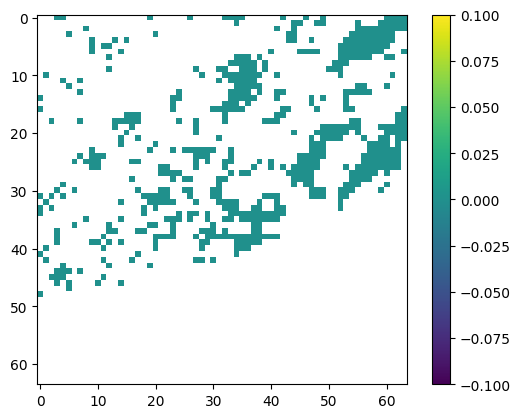

In [195]:
n_brain = ftonly.numpy()
# n_brain = brain_idx[5].numpy()
# n_brain = n_brain.reshape(16, 16)
max_val = np.max(n_brain)
n_brain = n_brain
n_brain = np.log(n_brain)

plt.imshow(n_brain)
plt.colorbar()

In [196]:
brain.unsqueeze_(0)
heart.unsqueeze_(0)
kidney.unsqueeze_(0)
liver.unsqueeze_(0)
lung.unsqueeze_(0)
pancreas.unsqueeze_(0)
spleen.unsqueeze_(0)

tensor([[[  272,   617,  1215,  2571,   635,   510,  1172,   863,  1211,  1386,
            291,   562,   764,   776,  1000,   736,  1134,   887,  1144,   650,
            387,   414,   577,   923,   950,  1692,  1171,  1488,  1025,   699,
           1976,  1594,   355,  1050,  1464,   616,  1196,   548,  3714,   794,
           1058,  1349,  5076,   555,   477,   566,  1062,  1285,  1353,   277,
           2901,   688,   845,   501,  1457,   314,   302,   541,   507,  1326,
            693,   950,  1855,   606,   399,   811,  1175,   598,  1603,  1005,
           1569,   700,  1298,   760,   405,   832,  1078,   261,  1521,   727,
           2213,   825,  1123,   808,  1187,  1334,   928,  1568,  1808,   453,
           1045,   580,   517,   947,   505,   815,  1440,   249,  1450,  2557,
            786,  1126,  1045,   626,  1215,   805,  1167,  1215,   901,  2528,
            843,   404,   346,   330,  1409,   585,  1293,   405,   999,   684,
            218,   559,  1322,   869,   

In [226]:
usages = torch.cat([brain, heart, kidney, liver, lung, pancreas, spleen], 0)

In [227]:
torch.set_printoptions(profile='default')
print(usages.shape)
print(usages)

torch.Size([756, 512])
tensor([[2785,  742,  104,  ...,    0,    0,    0],
        [2777,  711,  132,  ...,    0,    0,    0],
        [2708,  814,  112,  ...,    0,    0,    0],
        ...,
        [1103, 2298,  998,  ...,    0,    0,    0],
        [1112, 2197,  795,  ...,    0,    0,    0],
        [1174, 2160,  640,  ...,    0,    0,    0]])


In [228]:
for i in range(756):
    print(torch.argmax(usages[i]))

tensor(78)
tensor(78)
tensor(6)
tensor(78)
tensor(78)
tensor(6)
tensor(78)
tensor(103)
tensor(6)
tensor(78)
tensor(6)
tensor(78)
tensor(6)
tensor(78)
tensor(78)
tensor(78)
tensor(78)
tensor(6)
tensor(6)
tensor(6)
tensor(78)
tensor(6)
tensor(6)
tensor(6)
tensor(6)
tensor(78)
tensor(78)
tensor(103)
tensor(6)
tensor(78)
tensor(78)
tensor(6)
tensor(78)
tensor(6)
tensor(6)
tensor(6)
tensor(71)
tensor(78)
tensor(78)
tensor(6)
tensor(78)
tensor(78)
tensor(71)
tensor(78)
tensor(103)
tensor(6)
tensor(78)
tensor(78)
tensor(78)
tensor(78)
tensor(78)
tensor(103)
tensor(78)
tensor(78)
tensor(6)
tensor(78)
tensor(78)
tensor(71)
tensor(78)
tensor(78)
tensor(78)
tensor(78)
tensor(6)
tensor(78)
tensor(6)
tensor(6)
tensor(6)
tensor(103)
tensor(78)
tensor(6)
tensor(78)
tensor(78)
tensor(78)
tensor(6)
tensor(6)
tensor(71)
tensor(78)
tensor(6)
tensor(78)
tensor(103)
tensor(6)
tensor(71)
tensor(78)
tensor(71)
tensor(6)
tensor(6)
tensor(6)
tensor(71)
tensor(78)
tensor(6)
tensor(78)
tensor(78)
tensor(6)
tenso

PCAによる次元削減と可視化を実行中...


/opt/patho/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/patho/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/patho/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/patho/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31684 (\N{CJK UNIFIED IDEOGRAPH-7BC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/patho/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22258 (\N{CJK UNIFIED IDEOGRAPH-56F2}) missing from font(s) DejaVu Sans.
  fig.canvas.pri

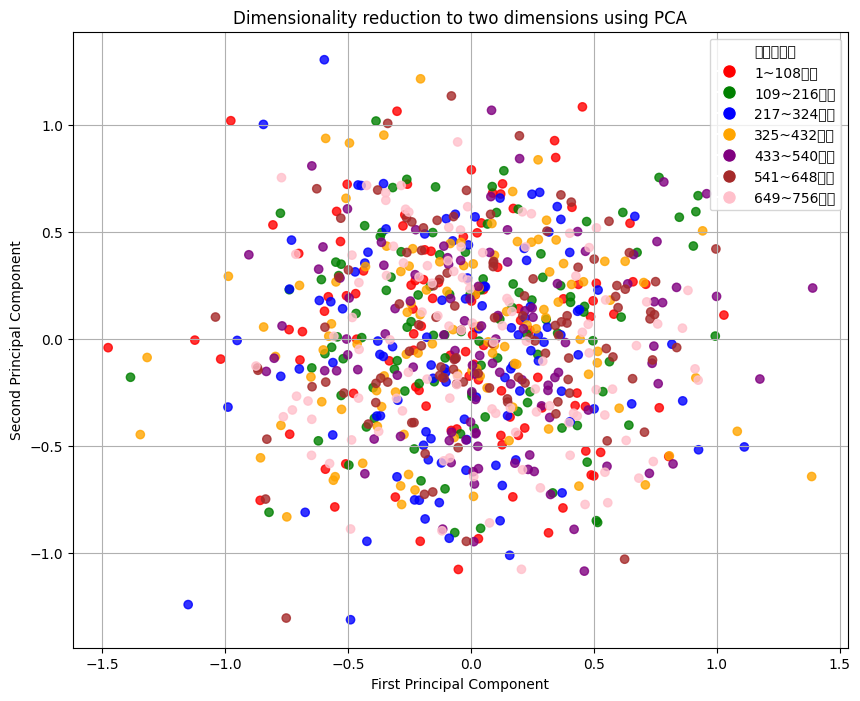

PCAの処理が完了しました。


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ダミーデータの生成 (実際のデータに置き換えてください)
# 756 x 256 の行列


print("PCAによる次元削減と可視化を実行中...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(usages)

# グループごとに色を割り当てるための準備
n_samples = X_pca.shape[0]  # 756
group_size = 108
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink']
# 各データポイントに対応する色の配列を作成
color_labels = np.repeat(colors, group_size)

# 結果の可視化
plt.figure(figsize=(10, 8))
# c引数に色の配列を指定
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=color_labels, alpha=0.8)

# 凡例の作成
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10) for c in colors]
labels = [f'{i*group_size + 1}~{(i+1)*group_size}番目' for i in range(len(colors))]
plt.legend(handles, labels, title="データ範囲")

plt.title('Dimensionality reduction to two dimensions using PCA')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True)
plt.show()

print("PCAの処理が完了しました。")

PCAによる次元削減と可視化を実行中...


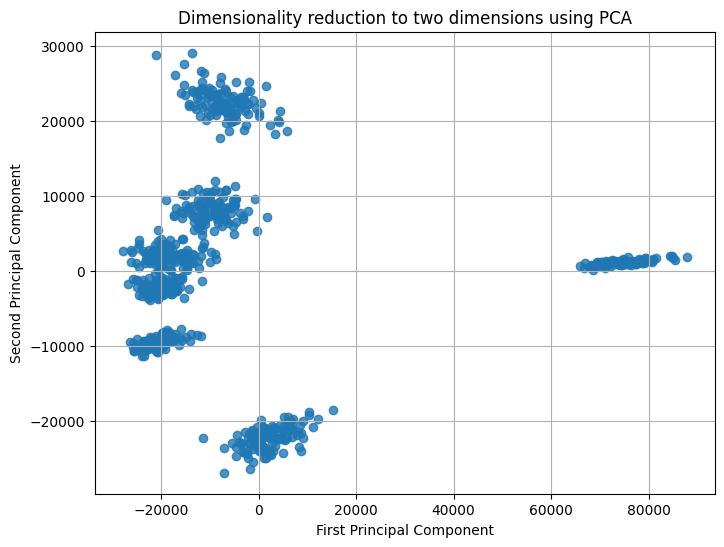

PCAの処理が完了しました。


In [229]:
print("PCAによる次元削減と可視化を実行中...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(usages)

# 結果の可視化
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.8)
plt.title('Dimensionality reduction to two dimensions using PCA')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True)
plt.show()

print("PCAの処理が完了しました。")

t-SNEによる次元削減と可視化を実行中...


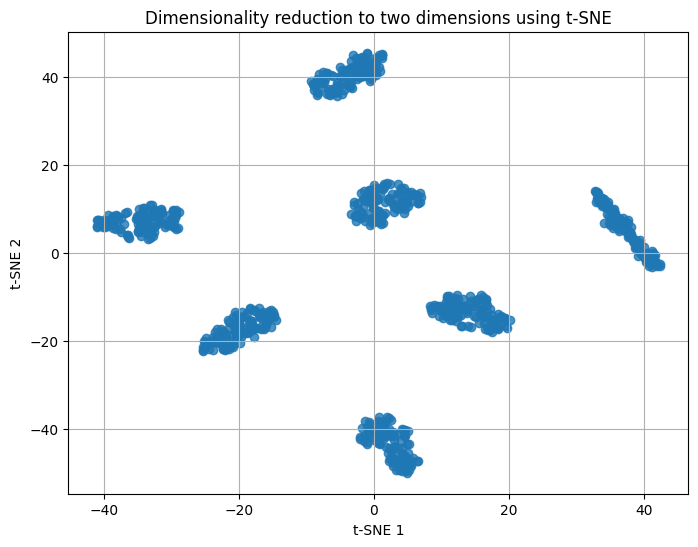

t-SNEの処理が完了しました。


In [230]:
print("t-SNEによる次元削減と可視化を実行中...")
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(usages)

# 結果の可視化
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.8)
plt.title('Dimensionality reduction to two dimensions using t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True)
plt.show()

print("t-SNEの処理が完了しました。")

UMAPによる次元削減と可視化を実行中...


/opt/patho/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/patho/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


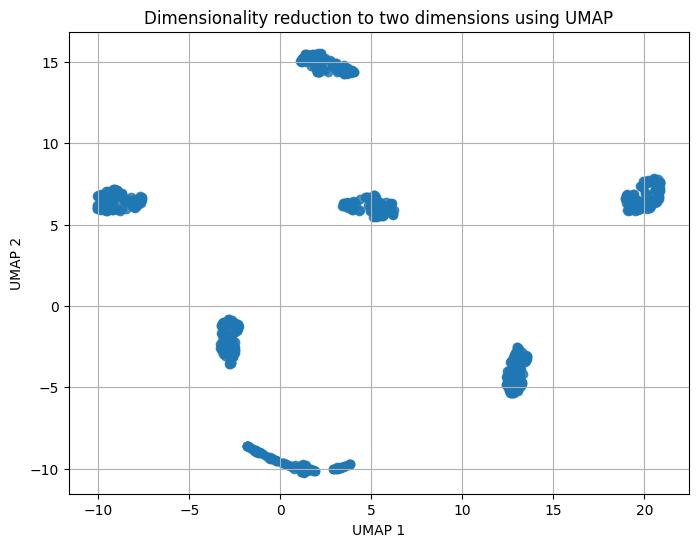

UMAPの処理が完了しました。


In [231]:
# --- UMAPによる次元削減と可視化 ---
print("UMAPによる次元削減と可視化を実行中...")
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(usages)

# 結果の可視化
plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.8)
plt.title('Dimensionality reduction to two dimensions using UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True)
plt.show()

print("UMAPの処理が完了しました。")

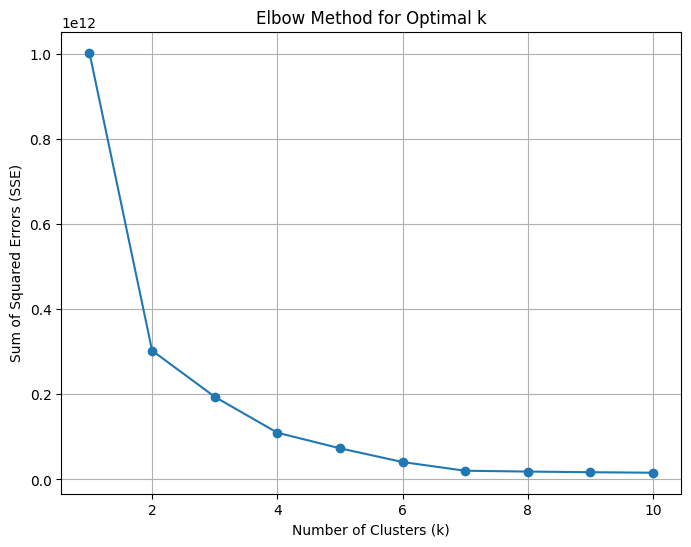

グラフを見て、SSEの減少が鈍化し始める点（肘）を見つけてください。それが最適なクラスター数です。


In [232]:
# SSEを格納するリスト
sse = []
# 試行するクラスター数の範囲
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(usages)
    # inertia_ はSSEに相当します
    sse.append(kmeans.inertia_)

# グラフのプロット
plt.figure(figsize=(8, 6))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()

print("グラフを見て、SSEの減少が鈍化し始める点（肘）を見つけてください。それが最適なクラスター数です。")

k-meansクラスタリングが完了しました。
各データポイントのクラスターラベル: [2 2 2 2 2 2 2 2 2 2]...


/opt/patho/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/patho/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


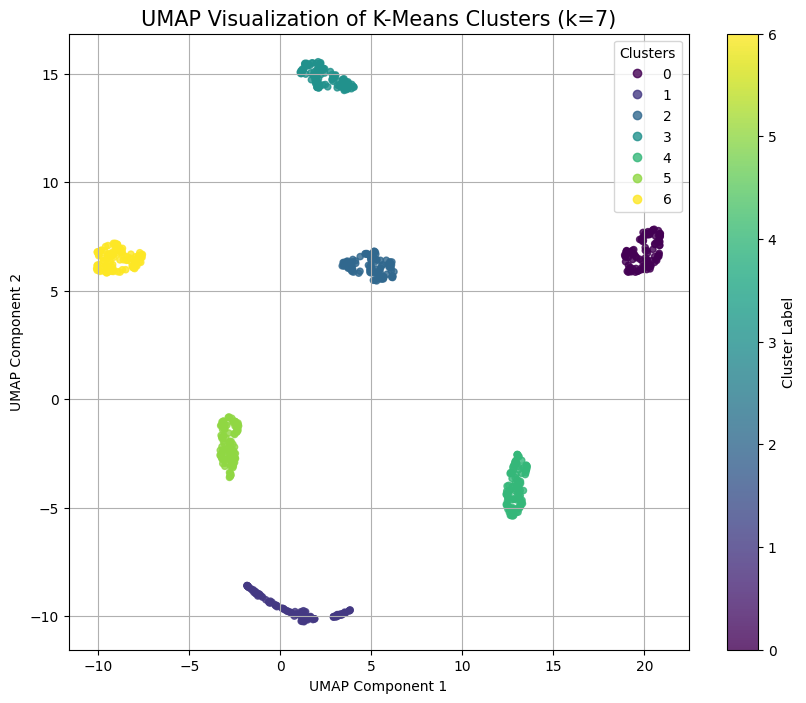

UMAPによる可視化が完了しました。


In [233]:
# 推定したクラスター数を入力
n_clusters = 7
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# クラスタリングを実行
kmeans.fit(usages)

# 各データポイントがどのクラスターに属するかを取得
cluster_labels = kmeans.labels_

print("k-meansクラスタリングが完了しました。")
print(f"各データポイントのクラスターラベル: {cluster_labels[:10]}...")

# UMAPのインスタンスを作成
reducer = umap.UMAP(n_components=2, random_state=42)

# 次元削減を実行
X_umap = reducer.fit_transform(usages)

# 可視化
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=cluster_labels, cmap='viridis', s=20, alpha=0.8)
plt.title(f'UMAP Visualization of K-Means Clusters (k={n_clusters})', fontsize=15)
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)

# カラーバーと凡例を追加
plt.colorbar(scatter, label='Cluster Label')
plt.legend(*scatter.legend_elements(), title='Clusters')
plt.show()

print("UMAPによる可視化が完了しました。")

In [48]:
n_brain = brain.numpy()
n_brain = n_brain.reshape(16, 16)
max_val = np.max(n_brain)
n_brain = n_brain / max_val
n_brain = np.log(n_brain)

plt.imshow(n_brain)
plt.colorbar()

ValueError: cannot reshape array of size 27648 into shape (16,16)

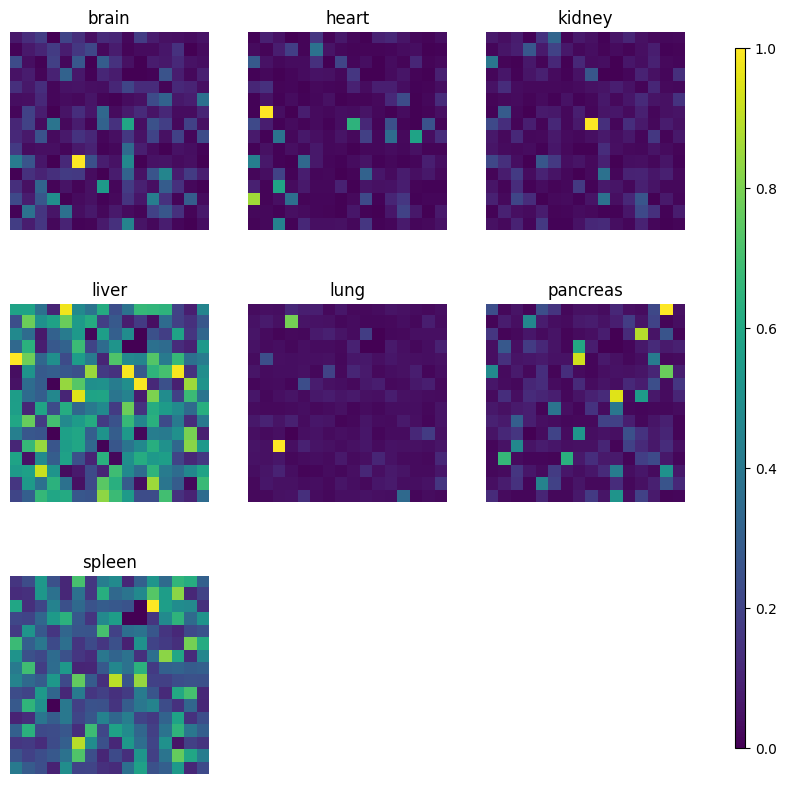

In [58]:
# 16x16のランダムなデータを7つ作成
data_list = [brain, heart, kidney, liver, lung, pancreas, spleen]

# 3行3列のサブプロットを作成 (合計9マス)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))

# axesを1次元配列に平坦化してループ処理を簡単にする
axes = axes.flatten()

# 各データをループでプロット
for i, data in enumerate(data_list):
    # i番目のサブプロットに画像を割り当てる
    data[0][42] = 0
    data = data.reshape(16, 16)
    data = data / torch.max(data)
    im = axes[i].imshow(data, cmap='viridis')
    axes[i].set_title(["brain", "heart", "kidney", "liver", "lung", "pancreas", "spleen"][i])
    axes[i].axis('off') # 軸を非表示にする

# 使用しないサブプロットを非表示にする
for j in range(len(data_list), len(axes)):
    axes[j].axis('off')

# タイトルとレイアウトの調整
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.01, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()

In [66]:
usage = usages.squeeze()
usage.shape

torch.Size([7, 256])

In [73]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA

# サンプルデータの作成
data = pd.DataFrame(usage)

print(data)
# MANOVAモデルの構築と実行
# 'Var1 + Var2 + Var3'が従属変数, 'Group'が独立変数
manova_test = MANOVA.from_formula('Var1 + Var2 + Var3 ~ Group', data=data)
print(data)
# 結果の取得と表示
print(manova_test.mv_test())

      0       1       2       3       4       5      6       7       8    \
0   64072  124480  172290    3530  200325  131023  38002  114456  104906   
1   14575  129789   69577    5022   19974  232786  22243   97268   32159   
2  106909   68949  119390   18728  232231  522639  20761  107840   69941   
3  148210  147961   95916   26984  252541  121953  99182  158940   61095   
4   37634   48202   46180  131658  102714  101205  31504   73246   29730   
5  203755   19846   43244   12196  202763  128835  19555   39449   37158   
6   49727   75093  171050   80216   35189  228444  51862  136668  154106   

     9    ...    246     247     248     249     250    251     252     253  \
0  21892  ...  14841   70432  135126  434999   49790  22107   76905   17778   
1  10946  ...  62277   67313   33893  235351   16894  25227  106212   25689   
2  13482  ...  13529   77299  176214  191585   57077  25735  151793   25454   
3  96697  ...  66538  213520  175746  140303   60033  60151  179893   36425

PatsyError: Error evaluating factor: NameError: name 'Var3' is not defined
    Var1 + Var2 + Var3 ~ Group
                  ^^^^